In [1]:
# Tutorial environment setup
using Pkg, NTRsurv
pkg_dir = pkgdir(NTRsurv)
Pkg.activate(joinpath(pkg_dir, "examples"))
Pkg.instantiate()

[ Info: Precompiling NTRsurv [44a71bb7-9d27-4d6a-8d2f-9a31f1763d85] (cache misses: include_dependency fsize change (2), wrong dep version loaded (4), mismatched flags (4))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
  Activating 
SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
project at `~/NTRsurv.jl/examples`
Precompiling packages...
   1433.8 ms  ✓ Distributions → DistributionsTestExt
   1903.9 ms  ✓ StatsModels
   1747.4 ms  ✓ Survival
  21528.6 ms  ✓ PrettyTables
  38337.3 ms  ✓ DataFrames
   1387.0 ms  ✓ Latexify → DataFramesExt
  6 dependencies successfully precompiled in 63 seconds. 276 already precompiled.


In [2]:
# Load neutral to the righ survival modeling package package
using Random, Plots, LaTeXStrings, CSV, DataFrames, Distributions, NTRsurv, Survival, Measures

In [3]:
# Set random number generator seed for reproducibility
Random.seed!(1234)

TaskLocalRNG()

# Cohort data for meta-analysis in breast cancer patients.

This tutorial shows how to perform a meta-analysis with cohort frailties NTR-Cox regression models using a cohort depending Cox regression function with the Julia package [NTRsurv.jl](https://github.com/alan7riva/NTRsurv.jl). For theoretical details see the Weibull simulation study in the examples folder of the package.

#### Meta-analysis breast cancer real data

In this example we use data from the R package `mcsurvdata` corresponding to patients with breast cancer in different cohorts. Observations with missing `cohort` value were removed from the data.

We consider a NTR model with LogNormal frailties in the different cohorts as

\begin{align*}
\epsilon_j & \stackrel{\text{i.i.d.}}{\sim}\text{Normal}(m,s^2),\quad j\in\{1,\ldots,c\},
\\
X_{i} | Y, Z_i & \stackrel{\text{i.i.d.}}{\sim} \text{NTR}\left( \exp(\epsilon_{Z_i})Y   \right),\quad i\in\{1,\ldots,n\},
\end{align*}

Denoting $\Gamma_j=\exp(\epsilon_j)$ and $\pmb{\Gamma}=\left( \Gamma_1,\ldots, \Gamma_c \right)$ we have that a priori
$$
S_i(t) = \mathbb{P}\left[ X_i>t \,\Big| Y,Z_i,\pmb{\Gamma}\right] = \exp\left( -\Gamma_{Z_{ i}} Y(t) \right).
$$

As $Y$ already controls the baseline specification we set $m=0$ to avoid indetifiability issues and assign $s\sim \text{Normal(0,1)}$ for the variance specification on $\pmb{\Gamma}$.

In [4]:
# Load data
data_path = joinpath( dirname(dirname(pathof(NTRsurv))), "examples", "data", "brcamcsurvdata.csv")
data = CSV.read(data_path, DataFrame)
first(data,7)

Row,cohort,status,event
,Float64,Float64,Float64
1,1.0,0.0,84.6333
2,1.0,1.0,163.1
3,1.0,0.0,164.933
4,1.0,1.0,7.8
5,1.0,0.0,164.333
6,1.0,0.0,99.5333
7,1.0,1.0,128.0


In [5]:
# Array of data in each cohort
dataArr = [ data[ data[:,1] .== i, :] for i in collect(1.0:1.0:5.0) ]

5-element Vector{DataFrame}:
 398×3 DataFrame
 Row │ cohort   status   event    
     │ Float64  Float64  Float64  
─────┼────────────────────────────
   1 │     1.0      0.0   84.6333
   2 │     1.0      1.0  163.1
   3 │     1.0      0.0  164.933
   4 │     1.0      1.0    7.8
   5 │     1.0      0.0  164.333
   6 │     1.0      0.0   99.5333
   7 │     1.0      1.0  128.0
   8 │     1.0      0.0   36.5667
   9 │     1.0      1.0   36.2667
  10 │     1.0      1.0  132.033
  11 │     1.0      0.0  163.533
  ⋮  │    ⋮        ⋮        ⋮
 389 │     1.0      0.0  140.5
 390 │     1.0      1.0   41.3667
 391 │     1.0      0.0  108.933
 392 │     1.0      1.0   42.7
 393 │     1.0      0.0  118.2
 394 │     1.0      1.0   28.5
 395 │     1.0      1.0   22.0333
 396 │     1.0      1.0   39.2
 397 │     1.0      1.0   55.4667
 398 │     1.0      0.0  110.967
                  377 rows omitted
 217×3 DataFrame
 Row │ cohort   status   event    
     │ Float64  Float64  Float64  
─────┼───────

In [10]:
# Data sample sizes by cohort
c_sizes = size.(dataArr)

5-element Vector{Tuple{Int64, Int64}}:
 (398, 3)
 (217, 3)
 (585, 3)
 (175, 3)
 (131, 3)

In [15]:
c_exfracs = [ sum( dataArr[i].status )/c_sizes[i][1] for i in 1:5]

5-element Vector{Float64}:
 0.2562814070351759
 0.2903225806451613
 0.37435897435897436
 0.21142857142857144
 0.24427480916030533

In [7]:
# Kaplan-Meier fits in each cohort
kmArr = [ fit(KaplanMeier, dataArr[i][:,3], Int.(dataArr[i][:,2])) for i in 1:5];

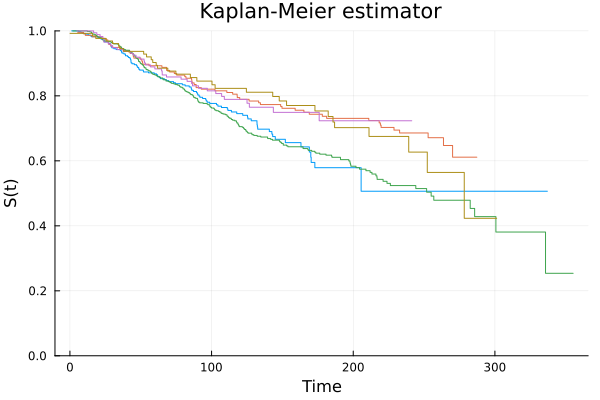

In [8]:
kmplt = plot(kmArr[1].events.time,kmArr[1].survival, seriestype = :steppost, xlabel = "Time", ylabel = "S(t)", label = "", ylim=(0,1), title="Kaplan-Meier estimator")
for i in 2:5
    plot!(kmArr[i].events.time,kmArr[i].survival, seriestype = :steppost, label="")
end
kmplt

In [9]:
# Survival data elements
T =  data[:,3]
δ =  Int64.(data[:,2])
Z = [ [v] for v in data[:,1] ];

In [10]:
# Survival data Struct for regression
datameta = RegressionSurvivalData( T, δ, Z)

NTRsurv.RegressionSurvivalDataRep([0.1, 1.233333333, 1.266666667, 1.433333333, 2.0, 2.3, 2.4, 2.533333333, 2.533333333, 2.866666667  …  300.8666667, 301.2333333, 307.6333333, 318.2, 330.3666667, 335.6, 335.7333333, 337.0333333, 351.0, 355.2], [0.1, 1.233333333, 1.266666667, 1.433333333, 2.0, 2.3, 2.4, 2.533333333, 2.866666667, 3.366666667  …  300.8666667, 301.2333333, 307.6333333, 318.2, 330.3666667, 335.6, 335.7333333, 337.0333333, 351.0, 355.2], [1, 0, 0, 0, 0, 0, 0, 0, 0, 0  …  0, 0, 0, 0, 0, 0, 1, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0, 0, 0, 0  …  0, 0, 0, 0, 0, 0, 1, 0, 0, 0], [[5.0], [1.0], [1.0], [1.0], [3.0], [5.0], [1.0], [3.0], [3.0], [1.0]  …  [3.0], [5.0], [3.0], [3.0], [3.0], [3.0], [3.0], [1.0], [3.0], [3.0]], [[[5.0]], Vector{Float64}[], Vector{Float64}[], Vector{Float64}[], Vector{Float64}[], Vector{Float64}[], Vector{Float64}[], Vector{Float64}[], Vector{Float64}[], Vector{Float64}[]  …  Vector{Float64}[], Vector{Float64}[], Vector{Float64}[], Vector{Float64}[], Vector{Float6

In [11]:
# NTR prior specification
λ = 1/500
α = 10.0

10.0

In [12]:
# Cox-NTR model baseline
baseline = ExponentialBaseline(λ)

Baseline(NTRsurv.var"#ExponentialBaseline##0#ExponentialBaseline##1"{Float64}(0.002), NTRsurv.var"#ExponentialBaseline##2#ExponentialBaseline##3"{Float64}(0.002), NTRsurv.var"#ExponentialBaseline##4#ExponentialBaseline##5"{Float64}(0.002))

In [13]:
# Plotting grid
t =  collect(LinRange(0.0,356.0,200))
# Prior survival band
prior_cred = prior_credible_band( 0.05, 3000, t, α, baseline )

([1.0, 0.6571478227504897, 0.6571478227504669, 0.6369186865667127, 0.6354424857198797, 0.6354424854105327, 0.6351100238789021, 0.6351100238789021, 0.6351100238788534, 0.6351100238788534  …  0.22162671695025885, 0.22162671695025885, 0.22162671695025885, 0.22152278822160007, 0.22152278822160007, 0.22152278822160007, 0.22152278800826947, 0.22152278800826947, 0.2037106418832612, 0.2037106418832612], [1.0, 0.99602278049247, 0.9924727684235924, 0.9888077991761006, 0.985584035433675, 0.9822137685454967, 0.9785506814850866, 0.9751125268104526, 0.9712301359246955, 0.9682771880886455  …  0.5062387097257797, 0.5044663953039342, 0.5024839036692033, 0.5004941036941314, 0.49883149911174357, 0.497135376509249, 0.495221442774764, 0.4937412736789893, 0.4920695185452546, 0.49045588419333686], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9999999999999898, 0.9999999999999885  …  0.7915336715506206, 0.7915336715506206, 0.7915284057262957, 0.7914859126197882, 0.7870651653292818, 0.7870651653292818, 0.78706516

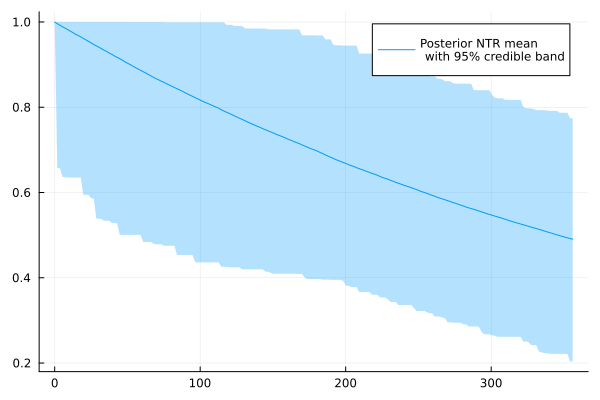

In [14]:
# Prior baseline illustration
plt_prior = plot(t, prior_cred[2],  ribbon = ( prior_cred[2] .- prior_cred[1],  prior_cred[3] .- prior_cred[2]), fillalpha=0.3, label="Posterior NTR mean \n with 95% credible band",size=(600,400))

In [15]:
# Meta-analysis Cox regression fuction
f(c::Vector{Float64},z::Vector{Float64}) = exp(c[Int(z[1])]) 

f (generic function with 1 method)

In [16]:
# Compilation runs
robbins_monro_mh_within_gibbs_tune(3, 3, x->NTRsurv.loglikelihood(x,α,baseline,f,datameta) + logpdf(Normal(0.0,exp(x[6])),x[1]) + logpdf(Normal(0.0,exp(x[6])),x[2]) + logpdf(Normal(0.0,exp(x[6])),x[3]) +  logpdf(Normal(0.0,exp(x[6])),x[4])  + logpdf(Normal(0.0,exp(x[6])),x[5]) + logpdf(Normal(),x[6]),ones(6), ones(6), 0.4.*ones(6), 0.7)

([[1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0634913484723583, 1.4467842341727166, 0.7817432769595243, 0.7817432769595243, 0.7817432769595243, 1.4467842341727166], [0.8835317934793192, 1.2019654612446036, 0.8188268965505427, 0.6494599514369258, 0.6494599514369258, 1.2019654612446036], [0.9176537961413386, 1.0329165932722524, 0.7036640533654728, 0.6745420982881861, 0.5581175018210232, 1.2483853738849104]], [1.227774143907035, 0.6933166388222056, 1.209116268891461, 1.0293289801565728, 1.0, 0.3046607807211055], -4751.9795043782415)

In [17]:
# Robbins-Monro algorithm run for tuning of Metropolis-Hastings variance proposal
sd_prop_tuned, s₀_tune, lliks₀_tune = robbins_monro_mh_within_gibbs_tune(100, 50, x->NTRsurv.loglikelihood(x,α,baseline,f,datameta) + logpdf(Normal(0.0,exp(x[6])),x[1]) + logpdf(Normal(0.0,exp(x[6])),x[2]) + logpdf(Normal(0.0,exp(x[6])),x[3]) +  logpdf(Normal(0.0,exp(x[6])),x[4])  + logpdf(Normal(0.0,exp(x[6])),x[5]) + logpdf(Normal(),x[6]),ones(6), ones(6), 0.4.*ones(6), 0.7)

Progress: 100%[==================================================] Time: 0:00:58


([[1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [0.8753210025791485, 0.8429457352093522, 0.8536022048457613, 0.9438496342853365, 0.8429457352093522, 1.005037726123811], [0.7918178072762002, 0.777093042648433, 0.757701166438233, 0.8538089976319071, 0.777093042648433, 1.0088473596933005], [0.7351629279038937, 0.7104186291945208, 0.6715915900632083, 0.8113244836195033, 0.7441583897262535, 1.0600342691364435], [0.6899291191011414, 0.6492977773975395, 0.6514637462396358, 0.7464435717184968, 0.7123685453416724, 1.0558353790120527], [0.6448705812457092, 0.6175865723869846, 0.6124730098725343, 0.7058660563687154, 0.6815336077185276, 1.0832335616254845], [0.613311176280374, 0.5904404819873905, 0.5886202565129157, 0.6819311260438822, 0.6653427470285829, 1.079841780357553], [0.5859139059192108, 0.5587200362436088, 0.5677052850171113, 0.6483746656754465, 0.6356211703996777, 1.061493830487597], [0.559311382724815, 0.5404125931184823, 0.5539387251624381, 0.6354313161612338, 0.6094274241344172, 1.0312227291861467]

In [18]:
# Metropolis-Hasting within Gibbs algorithm run
chain_s, _ =  random_walk_mh_within_gibbs( 3000, x->NTRsurv.loglikelihood(x,α,baseline,f,datameta) + logpdf(Normal(0.0,exp(x[6])),x[1]) + logpdf(Normal(0.0,exp(x[6])),x[2]) + logpdf(Normal(0.0,exp(x[6])),x[3]) +  logpdf(Normal(0.0,exp(x[6])),x[4])  + logpdf(Normal(0.0,exp(x[6])),x[5]) + logpdf(Normal(),x[6]), s₀_tune, lliks₀_tune, sd_prop_tuned[end])

([[0.10643054723367396, 0.003515543190531073, 0.35271045119375, 0.031484393236567515, -0.1942295199548059, -1.1539916283790934], [0.3066969709056687, 0.003515543190531073, 0.43786270453451376, 0.3966936314153411, -0.1942295199548059, -1.1539916283790934], [0.3066969709056687, 0.027585044970382458, 0.43786270453451376, 0.10816824513692275, 0.20829011424683155, -1.1539916283790934], [0.3066969709056687, 0.027585044970382458, 0.43786270453451376, 0.10816824513692275, 0.20829011424683155, -1.1539916283790934], [0.3066969709056687, 0.027585044970382458, 0.43786270453451376, -0.1919781574286542, 0.20829011424683155, -1.227849915071102], [0.3066969709056687, 0.027585044970382458, 0.30216819342093115, -0.1919781574286542, -0.2091922553964424, -1.227849915071102], [0.07001719742212964, 0.027585044970382458, 0.27329195730624767, -0.1284565843914947, -0.2091922553964424, -1.00073343658083], [0.06979186736553307, -0.2312050052281685, 0.27329195730624767, -0.1284565843914947, 0.013310189818043217, 

In [19]:
# Acceptance rate of MCMC chains
acceptance_rate(chain_s)

6-element Vector{Float64}:
 0.3627875958652884
 0.38779593197732576
 0.3614538179393131
 0.39613204401467156
 0.37279093031010335
 0.3844614871623875

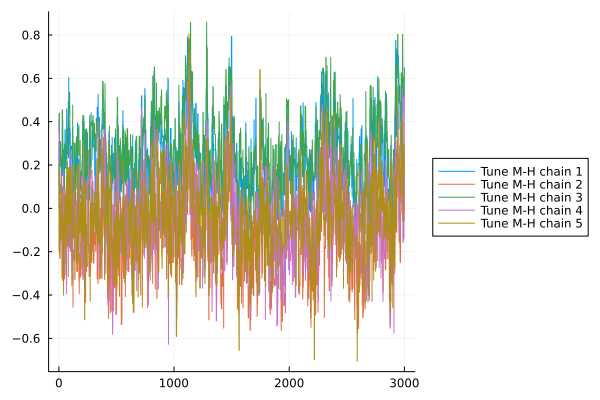

In [20]:
# Plot of MCMC chains for assessing converegence of posterior frailties
plot([ v[1] for v in chain_s],label="Tune M-H chain 1",legend=:outerright)
plot!([ v[2] for v in chain_s],label="Tune M-H chain 2")
plot!([ v[3] for v in chain_s],label="Tune M-H chain 3")
plot!([ v[4] for v in chain_s],label="Tune M-H chain 4")
plot!([ v[5] for v in chain_s],label="Tune M-H chain 5")

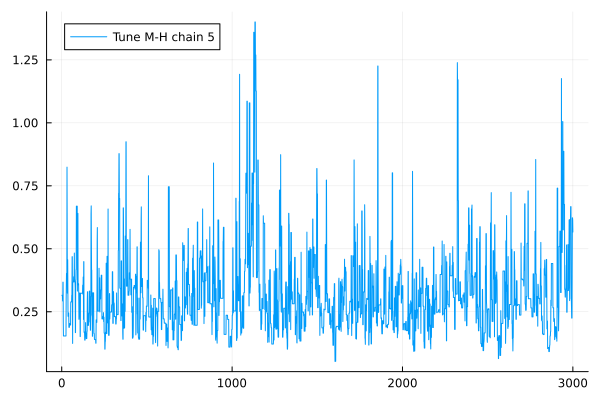

In [21]:
# Plot of MCMC chain for frailty variance parameters
plot([ exp(v[6]) for v in chain_s],label="Tune M-H chain 5")

In [22]:
# Cohort covariate vector
zv = [ [1.0], [2.0], [3.0], [4.0], [5.0] ];

In [23]:
# Fully Bayesian model fit
fully_bayes_cox_model = CoxNeutralToTheRightFullyBayesianModel( chain_s, α, baseline, f, datameta)

CoxNeutralToTheRightFullyBayesianModel([[0.10643054723367396, 0.003515543190531073, 0.35271045119375, 0.031484393236567515, -0.1942295199548059, -1.1539916283790934], [0.3066969709056687, 0.003515543190531073, 0.43786270453451376, 0.3966936314153411, -0.1942295199548059, -1.1539916283790934], [0.3066969709056687, 0.027585044970382458, 0.43786270453451376, 0.10816824513692275, 0.20829011424683155, -1.1539916283790934], [0.3066969709056687, 0.027585044970382458, 0.43786270453451376, 0.10816824513692275, 0.20829011424683155, -1.1539916283790934], [0.3066969709056687, 0.027585044970382458, 0.43786270453451376, -0.1919781574286542, 0.20829011424683155, -1.227849915071102], [0.3066969709056687, 0.027585044970382458, 0.30216819342093115, -0.1919781574286542, -0.2091922553964424, -1.227849915071102], [0.07001719742212964, 0.027585044970382458, 0.27329195730624767, -0.1284565843914947, -0.2091922553964424, -1.00073343658083], [0.06979186736553307, -0.2312050052281685, 0.27329195730624767, -0.12

In [24]:
# Computation of 95% posterior credible bands
fullyBayesNTR_bands = posterior_credible_band(0.05, t, zv, fully_bayes_cox_model)

5-element Vector{Tuple{Vector{Float64}, Vector{Float64}, Vector{Float64}}}:
 ([1.0, 0.994840904052503, 0.9945962506270627, 0.9945958970170862, 0.9901875465440209, 0.9887063618835344, 0.9857021711555195, 0.9829060179233992, 0.9821607170543285, 0.9700239701676543  …  0.23386533926351333, 0.23386533926351208, 0.2338653392626536, 0.2338653392612199, 0.2338136644479845, 0.23059688285925325, 0.23036717486630898, 0.23036717486630898, 0.23036709198272384, 0.22605243974123584], [1.0, 0.9992483662774245, 0.9992179912437604, 0.9991934799769164, 0.9977337578260909, 0.9970294714519444, 0.9955608321950825, 0.9933466298381349, 0.9918786862810042, 0.9867494689610936  …  0.3636504763935925, 0.3623021905337725, 0.3612185297309573, 0.3595948926748633, 0.3583028792770925, 0.3569385085038357, 0.35585311461382857, 0.35424083752562213, 0.35289452226222107, 0.3512443051938806], [1.0, 0.9999998852599037, 0.9999990913560141, 0.9999990913559436, 0.999939390155426, 0.9997717016422544, 0.9994730899426228, 0.998564

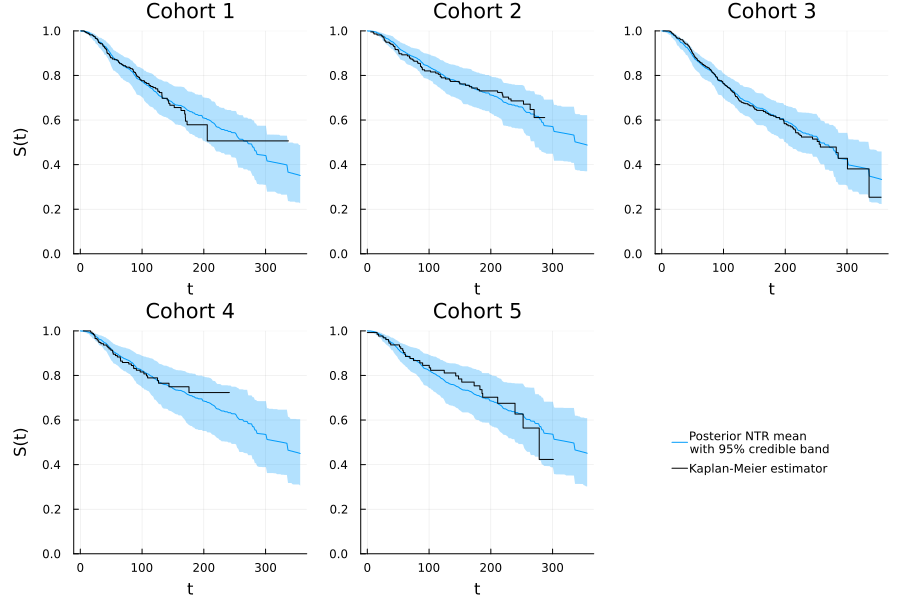

In [25]:
# Illustration of posterior cohort survival estimations
p_meta_1 = plot(t, fullyBayesNTR_bands[1][2],  ribbon = ( fullyBayesNTR_bands[1][2] .- fullyBayesNTR_bands[1][1], fullyBayesNTR_bands[1][3] .- fullyBayesNTR_bands[1][2]), fillalpha=0.3, label="",size=(600,400))
plot!(p_meta_1,kmArr[1].events.time,kmArr[1].survival, seriestype = :steppost, xlabel = "t", ylabel = "S(t)", label = "", c=:black, ylim=(0,1), title="Cohort 1", leftmargin=5mm)
p_meta_2 = plot(t, fullyBayesNTR_bands[2][2],  ribbon = ( fullyBayesNTR_bands[2][2] .- fullyBayesNTR_bands[2][1], fullyBayesNTR_bands[2][3] .- fullyBayesNTR_bands[2][2]), fillalpha=0.3, label="",size=(600,400))
plot!(p_meta_2,kmArr[2].events.time,kmArr[2].survival, seriestype = :steppost, xlabel = "t", ylabel = "", label = "", c=:black, ylim=(0,1), title="Cohort 2")
p_meta_3 = plot(t, fullyBayesNTR_bands[3][2],  ribbon = ( fullyBayesNTR_bands[3][2] .- fullyBayesNTR_bands[3][1], fullyBayesNTR_bands[3][3] .- fullyBayesNTR_bands[3][2]), fillalpha=0.3, label="",size=(600,400))
plot!(p_meta_3,kmArr[3].events.time,kmArr[3].survival, seriestype = :steppost, xlabel = "t", ylabel = "", label = "", c=:black, ylim=(0,1), title="Cohort 3")
p_meta_4 = plot(t, fullyBayesNTR_bands[4][2],  ribbon = ( fullyBayesNTR_bands[4][2] .- fullyBayesNTR_bands[4][1], fullyBayesNTR_bands[4][3] .- fullyBayesNTR_bands[4][2]), fillalpha=0.3, label="",size=(600,400))
plot!(p_meta_4,kmArr[4].events.time,kmArr[4].survival, seriestype = :steppost, xlabel = "t", ylabel = "S(t)", label = "", c=:black, ylim=(0,1), title="Cohort 4", leftmargin=5mm)
p_meta_5 = plot(t, fullyBayesNTR_bands[5][2],  ribbon = ( fullyBayesNTR_bands[5][2] .- fullyBayesNTR_bands[5][1], fullyBayesNTR_bands[5][3] .- fullyBayesNTR_bands[5][2]), fillalpha=0.3, label="",size=(600,400))
plot!(p_meta_5,kmArr[5].events.time,kmArr[5].survival, seriestype = :steppost, xlabel = "t", ylabel = "", label = "", c=:black, ylim=(0,1), title="Cohort 5")
p_legend = plot(
    [0], [0],
    ribbon = (fullyBayesNTR_bands[5][2] .- fullyBayesNTR_bands[5][1], fullyBayesNTR_bands[5][3] .- fullyBayesNTR_bands[5][2]),
    fillalpha = 0.3,
    label = "Posterior NTR mean \nwith 95% credible band",
    framestyle = :none,
    axis = false,
    legend=(0.15,0.5),
    foreground_color_legend=:transparent
)
plot!([0],[0],c=:black, label="Kaplan-Meier estimator ")
p_meta_cohorts = plot(p_meta_1, p_meta_2, p_meta_3, p_meta_4, p_meta_5, p_legend, layout = (2, 3), size = (900, 600),sup_title="")